In [40]:

# PHASE 1 & 2: PROBLEM UNDERSTANDING + DATA COLLECTION

!pip install imbalanced-learn xgboost -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Part 1: applicant info
part1 = """LP1001 Male Yes 0 Graduate No 2585
LP1002 Female No 0 Graduate No 6501
LP1003 Male No 1 Graduate Yes 5743
LP1004 Male Yes 0 Graduate No 9485
LP1005 Male Yes 3+ Graduate No 5481
LP1006 Male Yes 0 Graduate NA 5366
LP1007 Male Yes 1 Not_Graduate No 4059
LP1008 Male Yes 2 Not_Graduate No 6667
LP1009 Male Yes 0 Graduate No 3299
LP1010 Male No 1 Graduate No 4285
LP1011 Male Yes 0 Not_Graduate No 7847
LP1012 Female Yes 2 Graduate No 14894
LP1013 Male No 0 Graduate No 3694
LP1014 Male Yes 0 Graduate Yes 1500
LP1015 Male No 0 Graduate No 6322
LP1016 Male No 0 Graduate Yes 6346
LP1017 Male No 2 Not_Graduate No 5964
LP1018 Male No 2 Graduate No 5187
LP1019 Male Yes 2 Not_Graduate No 3489
LP1020 Male No 0 Graduate No 3798
LP1021 Male Yes 0 Graduate Yes 1500
LP1022 Male No NA Graduate No 3021
LP1023 Male Yes 1 Graduate No 5223
LP1024 Male No 2 Graduate No 3986
LP1025 Male Yes 0 Not_Graduate Yes 7120
LP1026 Male Yes 0 Graduate No 9896
LP1027 Female Yes 3+ Graduate No 1629
LP1028 Male Yes 3+ Graduate No 8012
LP1029 Male No 1 Graduate No 3924
LP1030 Female No 0 Graduate No 2395
LP1031 Male Yes 0 Graduate No 8772
LP1032 Male Yes 2 Graduate No 6207
LP1033 Male No 0 Graduate No 4644
LP1034 Male NA 0 Graduate No 6749
LP1035 Male Yes 0 Graduate No 4787
LP1036 Female Yes 1 Graduate No 1500
LP1037 Female Yes 0 Graduate No 1500
LP1038 Male No 1 Not_Graduate No 4172
LP1039 Male No 0 Graduate No 3603
LP1040 Male Yes 0 Not_Graduate No 1500
LP1041 Female Yes 0 Graduate No 4752
LP1042 Female NA 1 Graduate No 1500
LP1043 Male Yes 2 Graduate No 10628
LP1044 Male Yes 0 Graduate No 7673
LP1045 Male No 1 Not_Graduate No 6684
LP1046 Male No 0 Graduate No 1598
LP1047 Male Yes 0 Not_Graduate No 6466
LP1048 Male Yes 2 Graduate No 4314
LP1049 Male No 1 Graduate No 1500
LP1050 Female No NA Not_Graduate No 4236
LP1051 Female No 0 Graduate Yes 9853
LP1052 Female Yes 0 Graduate No 8348
LP1053 Male No 1 Graduate No 7963
LP1054 Male Yes 2 Graduate No 5583
LP1055 Male Yes 0 Graduate No 6649
LP1056 Female Yes 0 Graduate Yes 4735
LP1057 Female Yes 2 Graduate No 14037
LP1058 Male Yes 0 Graduate No 7526
LP1059 Male Yes 0 Graduate NA 2154
LP1060 Male Yes 2 Graduate NA 2620
LP1061 Male Yes 0 Graduate Yes 8896
LP1062 Male Yes 0 Graduate No 4018
LP1063 Male No 1 Not_Graduate No 10322
LP1064 Male Yes 3+ Graduate No 7242
LP1065 Male Yes 2 Graduate No 8347
LP1066 Male Yes 1 Not_Graduate No 11752
LP1067 Male Yes 0 Graduate No 9184
LP1068 Male No 3+ Graduate No 4573
LP1069 Male Yes 0 Not_Graduate No 7348
LP1070 Female No 2 Graduate No 6314
LP1071 Male Yes 2 Graduate No 3843
LP1072 Male No 0 Graduate No 5974
LP1073 Male Yes 3+ Graduate No 5587
LP1074 Male No 0 Graduate No 5072
LP1075 Male Yes 0 Graduate No 5387
LP1076 Male Yes 0 Graduate No 9435
LP1077 Female Yes 0 Graduate No 10465
LP1078 Male Yes 0 Graduate No 5034
LP1079 Female Yes 1 Not_Graduate Yes 6976
LP1080 Male No 0 Graduate No 2580
LP1081 Male No 2 Graduate No 8842
LP1082 Female Yes 1 Graduate No 1595
LP1083 Male No 0 Graduate No 7174
LP1084 Male Yes 0 Graduate No 7891
LP1085 Female Yes 1 Graduate No 1860
LP1086 Male Yes 1 Graduate No 5151
LP1087 Female Yes 2 Graduate Yes 2802
LP1088 Male No 0 Graduate No 6697
LP1089 Male Yes 1 Graduate Yes 10002
LP1090 Male Yes 0 Graduate Yes 5193
LP1091 Male Yes 2 Graduate No 12556
LP1092 Male Yes 3+ Graduate No 8606
LP1093 Male No 0 Graduate No 4109
LP1094 Male Yes 0 Graduate No 4859
LP1095 Male No 2 Graduate No 4239
LP1096 Female No 0 Graduate No 12053
LP1097 Male No 1 Graduate Yes 5626
LP1098 Male Yes 0 Graduate No 9715
LP1099 Male No 0 Graduate No 4951
LP1100 Male Yes 3+ Graduate No 7052
LP1101 Male No 1 Graduate NA 10461
LP1102 Male Yes 3+ Graduate No 7826
LP1103 Male Yes 0 Graduate NA 2224
LP1104 Male Yes 2 Graduate No 11068
LP1105 Male Yes 1 Graduate No 4627
LP1106 Female Yes 1 Not_Graduate No 1954
LP1107 Male Yes 0 Not_Graduate No 4405
LP1108 Male Yes 0 Graduate No 3868
LP1109 Male No 1 Graduate No 3989
LP1110 Female Yes NA Graduate Yes 5419
LP1111 Male Yes 0 Graduate Yes 3036
LP1112 Male Yes 1 Not_Graduate No 5990
LP1113 Male No 3+ Not_Graduate No 6218
LP1114 Male Yes 0 Graduate No 4428
LP1115 Male Yes 1 Not_Graduate No 1907
LP1116 Male No 0 Graduate Yes 9171
LP1117 Male Yes 2 Graduate No 7233
LP1118 Male Yes 1 Graduate Yes 2937
LP1119 Male Yes 0 Graduate No 1500
LP1120 Male No 0 Not_Graduate No 7561"""

# Part 2: loan/coapplicant info (same row order as part1)
part2 = """0 26 360 1 Urban Y
0 239 360 1 Semiurban Y
0 189 360 1 Semiurban N
0 98 360 1 Urban Y
0 217 360 0 Semiurban N
3377 127 120 1 Rural Y
0 114 84 0 Urban N
3046 202 300 1 Rural Y
0 208 360 1 Rural Y
1943 102 120 1 Rural Y
1171 133 84 NA Urban N
382 133 360 0 Rural N
3297 112 360 1 Urban Y
2905 177 360 0 Urban N
0 161 360 1 Rural Y
2397 195 360 1 Urban N
0 184 180 0 Semiurban N
0 94 360 1 Urban N
501 9 360 0 Urban N
2341 54 300 1 Urban Y
3193 207 360 1 Urban Y
1146 121 84 NA Semiurban N
1477 143 360 1 Rural Y
2455 73 120 1 Semiurban Y
0 187 360 1 Semiurban Y
0 138 360 1 Urban Y
0 31 360 1 Semiurban Y
242 58 300 1 Urban Y
3307 23 360 0 Urban N
122 238 180 1 Semiurban Y
0 49 120 1 Semiurban Y
2570 98 360 1 Semiurban Y
0 168 360 1 Rural N
0 215 360 1 Semiurban Y
0 194 360 1 Rural Y
1852 179 360 1 Urban Y
0 82 360 1 Urban Y
0 140 360 1 Semiurban Y
6290 202 360 1 Semiurban Y
3644 133 360 1 Urban N
0 89 360 1 Urban Y
1450 122 360 0 Rural N
2626 134 360 0 Semiurban N
528 47 360 1 Urban Y
842 110 360 1 Urban Y
1248 151 120 1 Urban Y
0 229 360 NA Semiurban N
1519 26 300 1 Urban Y
0 93 360 1 Urban Y
1709 153 360 1 Rural Y
0 89 360 1 Semiurban Y
1114 175 360 1 Semiurban Y
4077 104 360 NA Rural Y
1538 159 NA 1 Rural Y
653 152 360 1 Rural Y
3558 51 360 1 Rural Y
0 122 84 1 Semiurban Y
3111 69 84 1 Semiurban Y
146 71 360 1 Semiurban Y
0 74 180 1 Urban Y
172 99 360 1 Rural Y
0 91 360 1 Semiurban Y
0 200 360 1 Semiurban Y
0 167 360 1 Urban Y
0 166 360 1 Rural Y
2381 170 360 0 Semiurban N
603 208 180 1 Urban N
973 206 360 1 Urban N
0 155 120 1 Rural Y
1139 100 360 1 Rural Y
0 157 360 0 Urban N
0 204 360 1 Rural N
26 149 360 1 Rural Y
1371 91 360 1 Rural Y
1853 85 360 1 Rural Y
0 171 120 1 Semiurban Y
2691 103 84 1 Semiurban Y
772 48 300 1 Semiurban Y
0 150 360 1 Rural Y
3385 209 360 1 Rural N
2294 196 300 1 Semiurban Y
1267 68 180 1 Urban Y
0 76 360 0 Urban N
3292 48 360 1 Urban Y
321 176 360 1 Semiurban Y
0 185 360 1 Rural N
0 181 360 1 Semiurban Y
0 211 360 1 Semiurban Y
2135 106 120 1 Rural Y
537 260 120 1 Rural N
0 168 360 1 Urban Y
1182 53 120 1 Rural Y
1395 91 360 1 Semiurban Y
882 101 360 1 Rural Y
1333 187 360 1 Rural N
846 217 360 0 Semiurban N
0 114 360 1 Rural Y
0 138 360 1 Urban Y
0 190 360 1 Semiurban Y
1060 200 360 1 Rural N
1224 131 360 1 Urban Y
848 100 360 1 Urban Y
0 186 180 NA Rural N
0 153 360 1 Rural Y
0 106 360 1 Rural Y
3350 124 360 NA Urban N
0 103 300 1 Urban Y
0 98 120 1 Rural N
2799 52 360 1 Semiurban Y
3557 109 180 1 Rural Y
1393 249 360 1 Urban N
2776 68 120 1 Urban Y
4588 96 300 1 Semiurban Y
0 221 360 1 Urban N
0 150 360 1 Rural Y
0 109 360 1 Semiurban Y
1677 212 360 NA Semiurban N
0 277 360 1 Semiurban Y
0 180 NA 1 Rural Y
2362 179 360 1 Semiurban Y"""

p1 = [l.split() for l in part1.strip().split("\n")]
p2 = [l.split() for l in part2.strip().split("\n")]

cols1 = ["Loan_ID","Gender","Married","Dependents","Education","Self_Employed","ApplicantIncome"]
cols2 = ["CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History","Property_Area","Loan_Status"]

df1 = pd.DataFrame(p1, columns=cols1)
df2 = pd.DataFrame(p2, columns=cols2)
df = pd.concat([df1, df2], axis=1)

df["Education"] = df["Education"].str.replace("Not_Graduate", "Not Graduate")
df = df.replace("NA", np.nan)

for c in ["ApplicantIncome","CoapplicantIncome","LoanAmount","Loan_Amount_Term","Credit_History"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (120, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP1001,Male,Yes,0,Graduate,No,2585,0,26,360.0,1.0,Urban,Y
1,LP1002,Female,No,0,Graduate,No,6501,0,239,360.0,1.0,Semiurban,Y
2,LP1003,Male,No,1,Graduate,Yes,5743,0,189,360.0,1.0,Semiurban,N
3,LP1004,Male,Yes,0,Graduate,No,9485,0,98,360.0,1.0,Urban,Y
4,LP1005,Male,Yes,3+,Graduate,No,5481,0,217,360.0,0.0,Semiurban,N


In [41]:

# PHASE 3: DATA PREPROCESSING


print("Missing values before cleaning:\n", df.isna().sum())

df_clean = df.drop_duplicates().drop(columns=["Loan_ID"]).copy()

cat_cols = ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]
num_cols = ["LoanAmount", "Loan_Amount_Term"]

for c in cat_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].mode()[0])
for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())


for c in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]:
    q1, q3 = df_clean[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    df_clean[c] = df_clean[c].clip(q1 - 1.5*iqr, q3 + 1.5*iqr)


df_clean["Dependents"] = df_clean["Dependents"].replace("3+", "3").astype(int)

binary_maps = {
    "Gender": {"Male": 1, "Female": 0},
    "Married": {"Yes": 1, "No": 0},
    "Education": {"Graduate": 1, "Not Graduate": 0},
    "Self_Employed": {"Yes": 1, "No": 0},
    "Loan_Status": {"Y": 1, "N": 0},
}
for c, m in binary_maps.items():
    df_clean[c] = df_clean[c].map(m)

df_clean = pd.get_dummies(df_clean, columns=["Property_Area"], drop_first=True)

print("\nMissing values after cleaning:", df_clean.isna().sum().sum())
print("Cleaned shape:", df_clean.shape)
df_clean.to_csv("loan_data_clean.csv", index=False)
df_clean.head()

Missing values before cleaning:
 Loan_ID              0
Gender               0
Married              2
Dependents           3
Education            0
Self_Employed        5
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     2
Credit_History       7
Property_Area        0
Loan_Status          0
dtype: int64

Missing values after cleaning: 0
Cleaned shape: (120, 13)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,1,0,1,0,2585.0,0.0,26,360.0,1.0,1,False,True
1,0,0,0,1,0,6501.0,0.0,239,360.0,1.0,1,True,False
2,1,0,1,1,1,5743.0,0.0,189,360.0,1.0,0,True,False
3,1,1,0,1,0,9485.0,0.0,98,360.0,1.0,1,False,True
4,1,1,3,1,0,5481.0,0.0,217,360.0,0.0,0,True,False


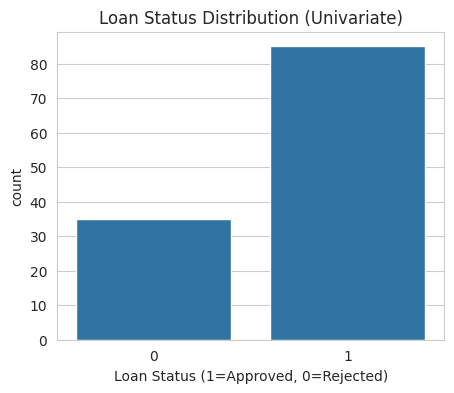

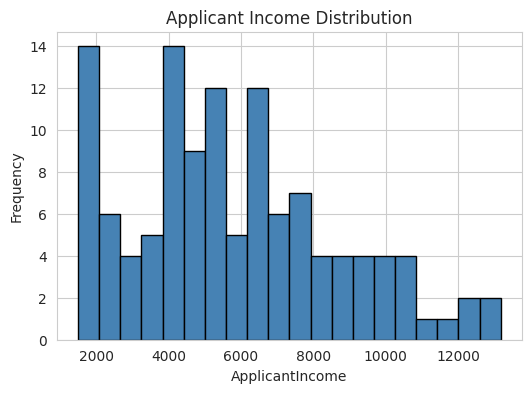

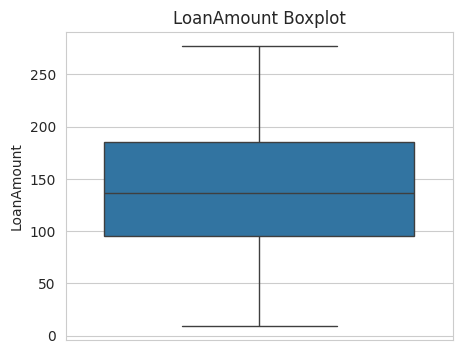

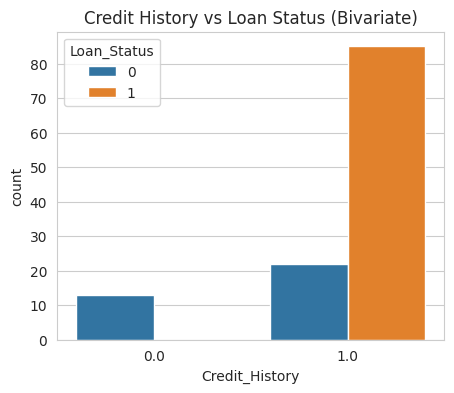

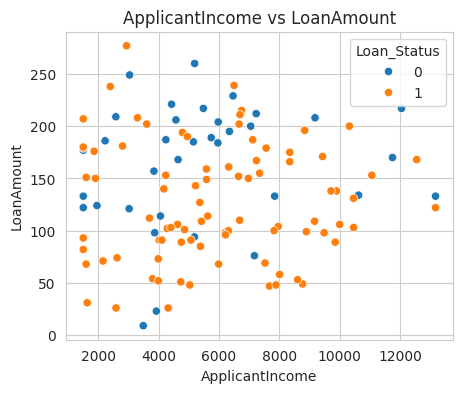

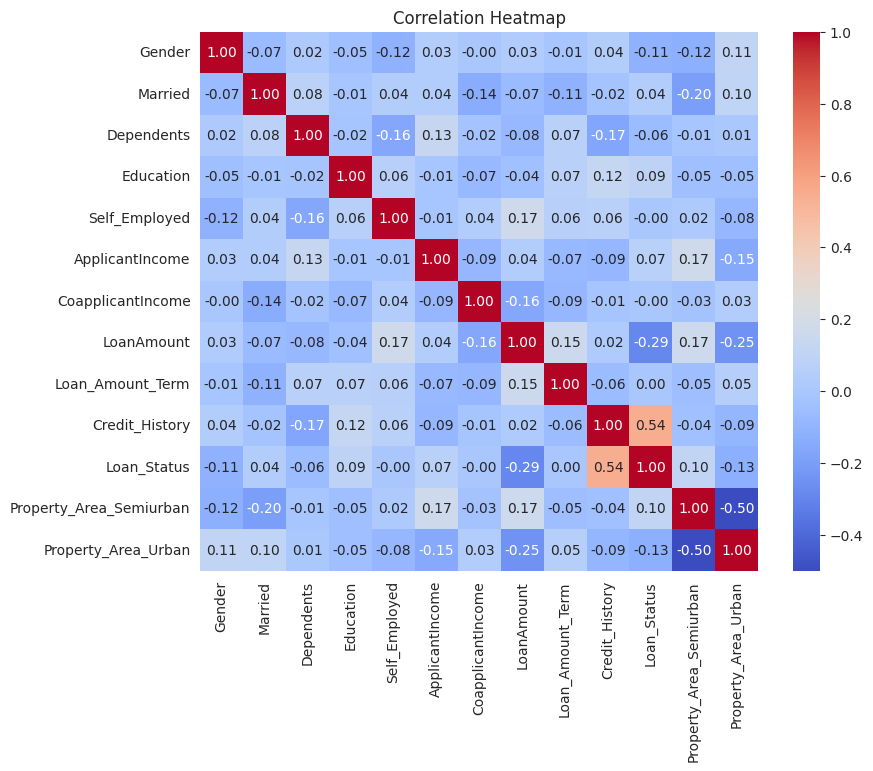


Correlation of each feature with Loan_Status:
Loan_Status                1.000000
Credit_History             0.543194
Property_Area_Semiurban    0.103713
Education                  0.090471
ApplicantIncome            0.066754
Married                    0.040268
Loan_Amount_Term           0.003389
CoapplicantIncome         -0.002037
Self_Employed             -0.002191
Dependents                -0.062650
Gender                    -0.114506
Property_Area_Urban       -0.129641
LoanAmount                -0.293553
Name: Loan_Status, dtype: float64


In [42]:

# PHASE 4: EXPLORATORY DATA ANALYSIS (EDA)


sns.set_style("whitegrid")

# ---- Univariate Analysis ----


plt.figure(figsize=(5,4))
sns.countplot(x="Loan_Status", data=df_clean)
plt.title("Loan Status Distribution (Univariate)")
plt.xlabel("Loan Status (1=Approved, 0=Rejected)")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(df_clean["ApplicantIncome"], bins=20, color="steelblue", edgecolor="black")
plt.title("Applicant Income Distribution")
plt.xlabel("ApplicantIncome"); plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(5,4))
sns.boxplot(y=df_clean["LoanAmount"])
plt.title("LoanAmount Boxplot")
plt.show()

# ---- Bivariate Analysis ----


plt.figure(figsize=(5,4))
sns.countplot(x="Credit_History", hue="Loan_Status", data=df_clean)
plt.title("Credit History vs Loan Status (Bivariate)")
plt.show()


plt.figure(figsize=(5,4))
sns.scatterplot(x="ApplicantIncome", y="LoanAmount", hue="Loan_Status", data=df_clean)
plt.title("ApplicantIncome vs LoanAmount")
plt.show()

# ---- Correlation Analysis ----


plt.figure(figsize=(9,7))
sns.heatmap(df_clean.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


print("\nCorrelation of each feature with Loan_Status:")
print(df_clean.corr(numeric_only=True)["Loan_Status"].sort_values(ascending=False))

In [43]:

# PHASE 5: FEATURE ENGINEERING



df_clean["TotalIncome"] = df_clean["ApplicantIncome"] + df_clean["CoapplicantIncome"]
df_clean["LoanAmount_to_Income"] = df_clean["LoanAmount"] / (df_clean["TotalIncome"] + 1)
df_clean["EMI"] = df_clean["LoanAmount"] / df_clean["Loan_Amount_Term"]

print("New features created: TotalIncome, LoanAmount_to_Income, EMI")
df_clean[["ApplicantIncome","CoapplicantIncome","TotalIncome","LoanAmount","LoanAmount_to_Income","EMI"]].head()


New features created: TotalIncome, LoanAmount_to_Income, EMI


,ApplicantIncome,CoapplicantIncome,TotalIncome,LoanAmount,LoanAmount_to_Income,EMI
0,2585.0,0.0,2585.0,26,0.010054,0.072222
1,6501.0,0.0,6501.0,239,0.036758,0.663889
2,5743.0,0.0,5743.0,189,0.032904,0.525000
3,9485.0,0.0,9485.0,98,0.010331,0.272222
4,5481.0,0.0,5481.0,217,0.039584,0.602778


In [44]:

feature_df = df_clean.drop(columns=["ApplicantIncome", "CoapplicantIncome"])


X = feature_df.drop(columns=["Loan_Status"])
y = feature_df["Loan_Status"]

print("Final selected features:")
print(list(X.columns))
print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

feature_df.to_csv("loan_data_features.csv", index=False)
feature_df.head()

Final selected features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area_Semiurban', 'Property_Area_Urban', 'TotalIncome', 'LoanAmount_to_Income', 'EMI']

Feature matrix shape: (120, 13)
Target shape: (120,)


,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban,TotalIncome,LoanAmount_to_Income,EMI
0,1,1,0,1,0,26,360.0,1.0,1,False,True,2585.0,0.010054,0.072222
1,0,0,0,1,0,239,360.0,1.0,1,True,False,6501.0,0.036758,0.663889
2,1,0,1,1,1,189,360.0,1.0,0,True,False,5743.0,0.032904,0.525000
3,1,1,0,1,0,98,360.0,1.0,1,False,True,9485.0,0.010331,0.272222
4,1,1,3,1,0,217,360.0,0.0,0,True,False,5481.0,0.039584,0.602778


In [45]:

# PHASE 6: MODEL BUILDING


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# ---- Data Balancing ----

print("\nClass balance BEFORE SMOTE:", y_train.value_counts().to_dict())

sm = SMOTE(random_state=42, k_neighbors=min(5, y_train.value_counts().min()-1))
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)

print("Class balance AFTER SMOTE:", y_train_bal.value_counts().to_dict())

Train shape: (96, 13)  Test shape: (24, 13)

Class balance BEFORE SMOTE: {1: 68, 0: 28}
Class balance AFTER SMOTE: {0: 68, 1: 68}


In [46]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)

# ---- Train  ----
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42),
}

fitted_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train_bal)
    fitted_models[name] = model
    print(f"{name} trained ✅")

Logistic Regression trained ✅
Random Forest trained ✅
XGBoost trained ✅


In [47]:

# PHASE 7: MODEL EVALUATION


from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve)

results = {}

for name, model in fitted_models.items():
    pred = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    }

results_df = pd.DataFrame(results).T.sort_values("F1 Score", ascending=False)
print("Model Comparison:")
print(results_df.round(3))

best_name = results_df.index[0]
best_model = fitted_models[best_name]
print(f"\n🏆 Best model: {best_name}")

Model Comparison:
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
XGBoost                 0.917      0.895   1.000     0.944    0.815
Logistic Regression     0.875      0.889   0.941     0.914    0.874
Random Forest           0.833      0.842   0.941     0.889    0.857

🏆 Best model: XGBoost


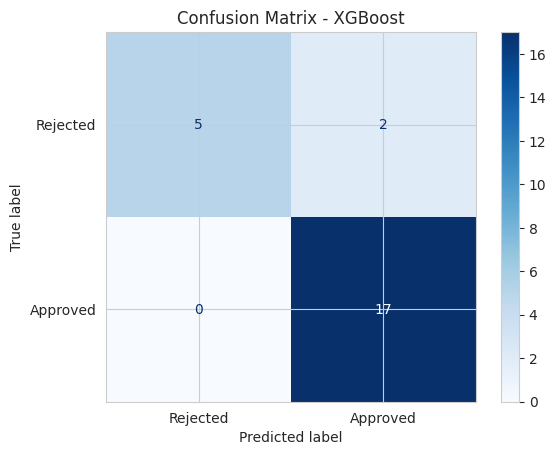

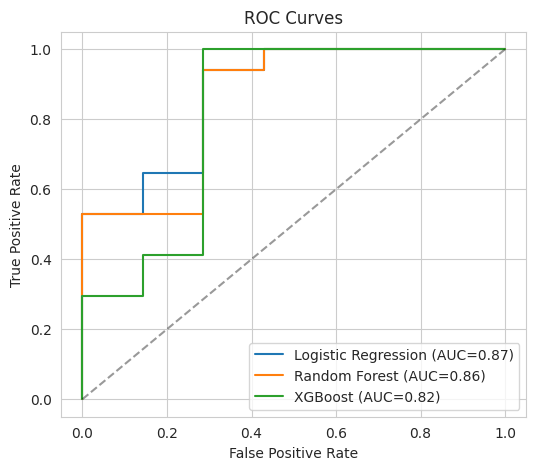

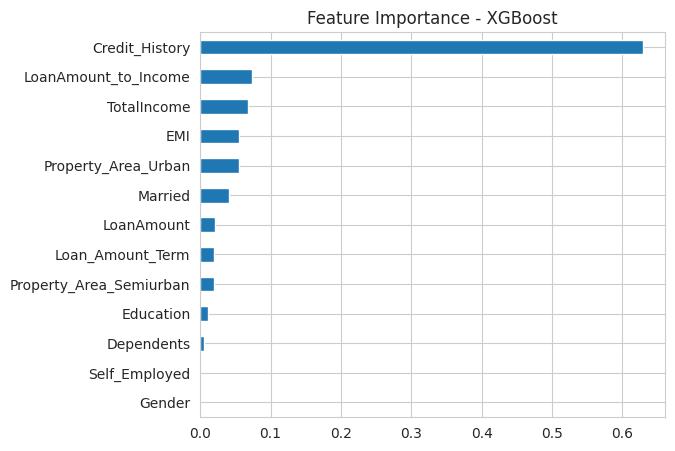

In [48]:

pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Rejected","Approved"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_name}")
plt.show()


plt.figure(figsize=(6,5))
for name, model in fitted_models.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={results[name]['ROC-AUC']:.2f})")
plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(6,5))
    imp.plot(kind="barh")
    plt.title(f"Feature Importance - {best_name}")
    plt.gca().invert_yaxis()
    plt.show()

In [49]:

import joblib

joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "feature_columns.pkl")

print(f"Saved: best_model.pkl, scaler.pkl, feature_columns.pkl (model = {best_name})")

Saved: best_model.pkl, scaler.pkl, feature_columns.pkl (model = XGBoost)


In [50]:
import os
for f in ["best_model.pkl", "scaler.pkl", "feature_columns.pkl"]:
    print(f, "✅ found" if os.path.exists(f) else "❌ missing")

best_model.pkl ✅ found
scaler.pkl ✅ found
feature_columns.pkl ✅ found


In [51]:
!pip install -q streamlit

In [52]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import time


st.set_page_config(
    page_title="🏦 AI Loan Approval Prediction System",
    page_icon="🏦",
    layout="wide",
    initial_sidebar_state="expanded"
)


model = joblib.load("best_model.pkl")
scaler = joblib.load("scaler.pkl")
feature_cols = joblib.load("feature_columns.pkl")


st.markdown("""
<style>

html, body, [class*="css"]{
    font-family: 'Segoe UI', sans-serif;
}

.main{
    background:#f4f8fc;
}

[data-testid="stSidebar"]{
    background:#0F4C81;
}

[data-testid="stSidebar"] *{
    color:white;
}

.big-title{
    font-size:42px;
    font-weight:bold;
    color:white;
    text-align:center;
}

.subtitle{
    font-size:18px;
    color:white;
    text-align:center;
}

.header{
    padding:30px;
    border-radius:20px;
    background:linear-gradient(90deg,#0F4C81,#3A86FF);
    margin-bottom:25px;
}

.card{
    background:white;
    padding:20px;
    border-radius:15px;
    box-shadow:0px 3px 15px rgba(0,0,0,0.12);
    margin-bottom:20px;
}

.metric-card{
    background:#EDF5FF;
    padding:15px;
    border-radius:15px;
    border-left:6px solid #0F4C81;
}

.result-success{
    background:#D4EDDA;
    padding:25px;
    border-radius:15px;
    border-left:8px solid green;
}

.result-fail{
    background:#F8D7DA;
    padding:25px;
    border-radius:15px;
    border-left:8px solid red;
}

.footer{
    text-align:center;
    color:gray;
    margin-top:50px;
    padding:20px;
}

</style>
""", unsafe_allow_html=True)


st.markdown("""
<div class="header">
<div class="big-title">🏦 AI Loan Approval Prediction System</div>
<div class="subtitle">
Predict whether a customer's loan application will be Approved or Rejected using Machine Learning
</div>
</div>
""", unsafe_allow_html=True)


st.markdown("## 📝 Applicant Information")

with st.form("loan_form"):

    col1, col2 = st.columns(2)

    with col1:

        st.markdown("### 👤 Personal Details")

        gender = st.selectbox(
            "Gender",
            ["Male","Female"]
        )

        married = st.selectbox(
            "Married",
            ["Yes","No"]
        )

        dependents = st.selectbox(
            "Dependents",
            ["0","1","2","3"]
        )

        education = st.selectbox(
            "Education",
            ["Graduate","Not Graduate"]
        )

        self_employed = st.selectbox(
            "Self Employed",
            ["Yes","No"]
        )

        property_area = st.selectbox(
            "Property Area",
            ["Urban","Semiurban","Rural"]
        )

    with col2:

        st.markdown("### 💰 Financial Details")

        applicant_income = st.number_input(
            "Applicant Monthly Income",
            min_value=0,
            value=4000
        )

        coapplicant_income = st.number_input(
            "Coapplicant Monthly Income",
            min_value=0,
            value=0
        )

        loan_amount = st.number_input(
            "Loan Amount (Thousands)",
            min_value=0,
            value=120
        )

        loan_term = st.selectbox(
            "Loan Term (Months)",
            [360,300,180,120,84,60,36,12]
        )

        credit_history = st.selectbox(
            "Credit History",
            ["Yes","No"]
        )
    predict = st.form_submit_button(
        "🔍 Predict Loan Status",
        use_container_width=True
    )



if predict:

    total_income = applicant_income + coapplicant_income

    loan_ratio = loan_amount / (total_income + 1)

    emi = loan_amount / loan_term

    row = {
        "Gender": 1 if gender == "Male" else 0,
        "Married": 1 if married == "Yes" else 0,
        "Dependents": int(dependents),
        "Education": 1 if education == "Graduate" else 0,
        "Self_Employed": 1 if self_employed == "Yes" else 0,
        "LoanAmount": loan_amount,
        "Loan_Amount_Term": loan_term,
        "Credit_History": 1 if credit_history == "Yes" else 0,
        "Property_Area_Semiurban": 1 if property_area == "Semiurban" else 0,
        "Property_Area_Urban": 1 if property_area == "Urban" else 0,
        "TotalIncome": total_income,
        "LoanAmount_to_Income": loan_ratio,
        "EMI": emi
    }

    X_input = pd.DataFrame([row])[feature_cols]

    X_scaled = scaler.transform(X_input)

    with st.spinner("🤖 AI is analysing the application..."):
        time.sleep(2)

    prediction = model.predict(X_scaled)[0]

    probability = model.predict_proba(X_scaled)[0][1]

    st.markdown("---")

    st.header("📊 Prediction Dashboard")

    m1, m2, m3 = st.columns(3)

    with m1:
        st.metric(
            "💵 Total Income",
            f"₹ {total_income:,.0f}"
        )

    with m2:
        st.metric(
            "🏦 Loan Amount",
            f"{loan_amount} K"
        )

    with m3:
        st.metric(
            "📅 Estimated EMI",
            f"{emi:.2f}"
        )

    st.markdown("---")

    st.subheader("🎯 Approval Probability")

    progress = 0

    bar = st.progress(0)

    while progress < int(probability * 100):
        progress += 1
        time.sleep(0.01)
        bar.progress(progress)

    st.metric(
        "Approval Chance",
        f"{probability:.1%}"
    )

    st.markdown("---")

    if prediction == 1:

        st.markdown("""
        <div class="result-success">
        <h2>✅ LOAN APPROVED</h2>
        <h4>
        Congratulations! The applicant is likely eligible for the requested loan.
        </h4>
        </div>
        """, unsafe_allow_html=True)

    else:

        st.markdown("""
        <div class="result-fail">
        <h2>❌ LOAN REJECTED</h2>
        <h4>
        Based on the available information, the loan is unlikely to be approved.
        </h4>
        </div>
        """, unsafe_allow_html=True)

    st.markdown("---")

    st.header("📋 Applicant Summary")

    summary = pd.DataFrame({

        "Field":[
            "Gender",
            "Married",
            "Dependents",
            "Education",
            "Self Employed",
            "Property Area",
            "Applicant Income",
            "Coapplicant Income",
            "Total Income",
            "Loan Amount",
            "Loan Term",
            "Credit History"
        ],

        "Value":[
            gender,
            married,
            dependents,
            education,
            self_employed,
            property_area,
            applicant_income,
            coapplicant_income,
            total_income,
            loan_amount,
            loan_term,
            credit_history
        ]

    })

    st.dataframe(
        summary,
        use_container_width=True,
        hide_index=True
    )

    st.markdown("---")

    st.subheader("📈 Financial Indicators")

    c1, c2, c3 = st.columns(3)

    with c1:
        st.info(f"💰 **Total Income**\n\n₹ {total_income:,.0f}")

    with c2:
        st.info(f"🏦 **Loan / Income Ratio**\n\n{loan_ratio:.4f}")

    with c3:
        st.info(f"📅 **Estimated EMI**\n\n{emi:.2f}")

    st.markdown("---")
    # =====================================================
    # AI DECISION INSIGHTS
    # =====================================================

    st.markdown("## 🤖 AI Decision Insights")

    score = probability * 100

    if score >= 85:
        level = "🟢 Very High Approval Chance"
        color = "green"

    elif score >= 70:
        level = "🟢 High Approval Chance"
        color = "green"

    elif score >= 50:
        level = "🟡 Moderate Approval Chance"
        color = "orange"

    elif score >= 30:
        level = "🟠 Low Approval Chance"
        color = "darkorange"

    else:
        level = "🔴 Very Low Approval Chance"
        color = "red"

    st.markdown(
        f"""
<div style='padding:20px;
background:white;
border-radius:15px;
border-left:8px solid {color};
box-shadow:0px 3px 12px rgba(0,0,0,0.1);'>

<h2>AI Confidence Score</h2>

<h1 style='color:{color};'>
{score:.1f}%
</h1>

<h3>{level}</h3>

</div>
""",
        unsafe_allow_html=True,
    )

    st.markdown("---")

    # =====================================================
    # RECOMMENDATIONS
    # =====================================================

    st.header("💡 Loan Recommendations")

    if prediction == 1:

        st.success("""
✔ Strong credit history improves approval chances.

✔ Continue maintaining stable income.

✔ Keep financial records updated.

✔ Timely EMI payments will improve future eligibility.
""")

    else:

        st.warning("""
Suggestions to improve approval chances:

• Improve credit history.

• Reduce requested loan amount.

• Increase monthly income.

• Apply with a co-applicant having stable income.

• Reduce existing liabilities before applying.
""")

    st.markdown("---")

    # =====================================================
    # INPUT SUMMARY CARDS
    # =====================================================

    st.header("📊 Quick Applicant Overview")

    a, b, c, d = st.columns(4)

    with a:
        st.metric("Applicant", gender)

    with b:
        st.metric("Education", education)

    with c:
        st.metric("Dependents", dependents)

    with d:
        st.metric("Area", property_area)

    st.markdown("---")

    # =====================================================
    # MODEL INFORMATION
    # =====================================================

    with st.expander("🧠 Machine Learning Model Details"):

        st.write("""
### Best Performing Model

The prediction shown above is generated using the best-performing
machine learning model selected during model evaluation.

The project compared:

• Logistic Regression

• Random Forest

• XGBoost

The best model was saved after evaluating:

✔ Accuracy

✔ Precision

✔ Recall

✔ F1 Score

✔ ROC-AUC

The same trained model is used for every prediction.
""")

    st.markdown("---")

    # =====================================================
    # THANK YOU MESSAGE
    # =====================================================

    st.balloons()

# =====================================================
# FOOTER
# =====================================================

st.markdown(
"""
<hr>

<div style="text-align:center;">

<h3>🏦 AI Loan Approval Prediction System</h3>

Built with using

<b>Python • Streamlit • Scikit-Learn • XGBoost</b>

<br><br>

Machine Learning Project

</div>
""",
unsafe_allow_html=True
)

Overwriting app.py


In [53]:
!ls

app.py		drive		     loan_data_features.csv  scaler.pkl
best_model.pkl	feature_columns.pkl  logs.txt
cloudflared	loan_data_clean.csv  sample_data


In [54]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!cat /content/logs.txt

In [55]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

In [56]:
!./cloudflared tunnel --url http://localhost:8501

2026-07-03T08:20:44Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-03T08:20:44Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-03T08:20:47Z INF +--------------------------------------------------------------------------------------------+
2026-07-03T08:20:47Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-03T08:20:47Z INF |  https://mainly-genetics-pounds-scale.trycloudflare.co